In [58]:
import kagglehub
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib as plt

In [42]:
path = kagglehub.competition_download('learning-agency-lab-automated-essay-scoring-2')
train_df = pd.read_csv(f'{path}/train.csv')
test_df = pd.read_csv(f'{path}/test.csv')

In [43]:
train_df.head()

,essay_id,full_text,score
0,000d118,Many people have car where they live. The thin...,3
1,000fe60,I am a scientist at NASA that is discussing th...,3
2,001ab80,People always wish they had the same technolog...,4
3,001bdc0,"We all heard about Venus, the planet without a...",4
4,002ba53,"Dear, State Senator\n\nThis is a letter to arg...",3


In [44]:
test_df.head()

,essay_id,full_text
0,000d118,Many people have car where they live. The thin...
1,000fe60,I am a scientist at NASA that is discussing th...
2,001ab80,People always wish they had the same technolog...


In [45]:
train_df['word_count'] = train_df['full_text'].str.split(' ').str.len()
test_df['word_count'] = test_df['full_text'].str.split(' ').str.len()

train_df['num_sentences'] = train_df['full_text'].apply(lambda x: len([s for s in re.split(r'[.!?]+', str(x)) if s.strip()]))
test_df['num_sentences'] = test_df['full_text'].apply(lambda x: len([s for s in re.split(r'[.!?]+', str(x)) if s.strip()]))

train_df['sentence_length'] = train_df[['num_sentences', 'word_count']].apply(lambda row: row['word_count']/row['num_sentences'], axis=1)
test_df['sentence_length'] = test_df[['num_sentences', 'word_count']].apply(lambda row: row['word_count']/row['num_sentences'], axis=1)

train_df['num_para'] = train_df['full_text'].apply(lambda x: len([p for p in str(x).split('\n') if p.strip()]))
test_df['num_para'] = test_df['full_text'].apply(lambda x: len([p for p in str(x).split('\n') if p.strip()]))

train_df['para_length'] = train_df [['num_para', 'word_count']].apply(lambda row: row['word_count']/row['num_para'], axis=1)
test_df['para_length'] = test_df [['num_para', 'word_count']].apply(lambda row: row['word_count']/row['num_para'], axis=1)

Text(0.5, 1.0, 'Score Distribution')

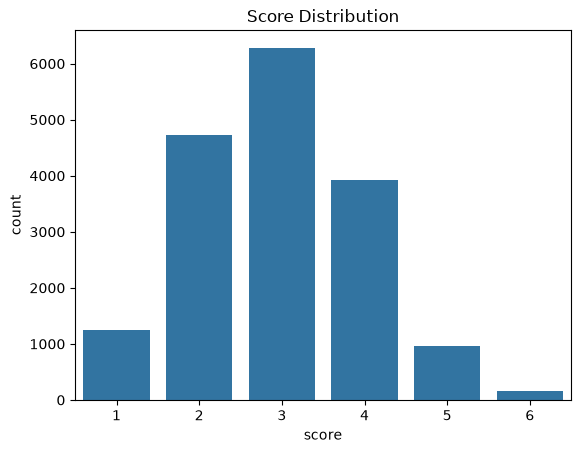

In [65]:
sns.countplot(
    data=train_df,
    x='score'
).set_title("Score Distribution")

Score seems to be normally distributed, with most essays scoring a 3. The classes are NOT evenly distributed --> class imbalance.

In [131]:
train_df['score'].value_counts()

score
3    6280
2    4723
4    3926
1    1252
5     970
6     156
Name: count, dtype: int64

Text(0.5, 1.0, 'Word Count vs Score')

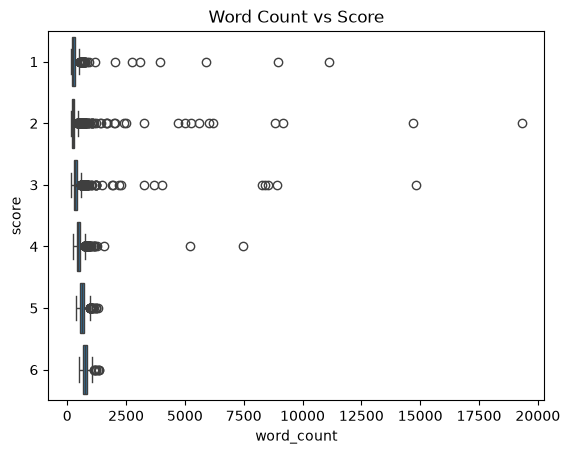

In [126]:
sns.boxplot(
    data = train_df,
    x='word_count',
    y='score',
    orient='h'
).set_title('Word Count vs Score')

When looking at the total word count per essay, essays that had more words generally scored higher. There seems to be a positive correlation here. However, there are many outliers for essays scoring 1-4. Thus, word count cannot be the sole determinator for score (ex. if an essay has 12500 words it's not automatically a 6). Further, the bars overlap, so word count may not be significant.

Text(0.5, 1.0, 'Score vs Number of Sentences')

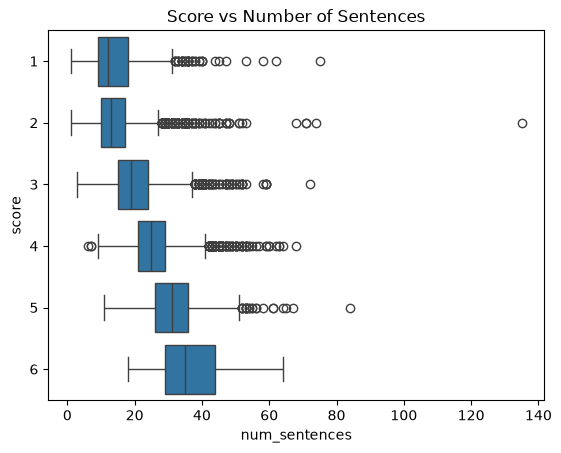

In [128]:
sns.boxplot(
    data = train_df,
    x = 'num_sentences',
    y='score',
    orient='h'
).set_title('Score vs Number of Sentences')

Essays with more sentences also generally had higher scores.

Text(0.5, 1.0, 'Score vs Number of Paragraphs')

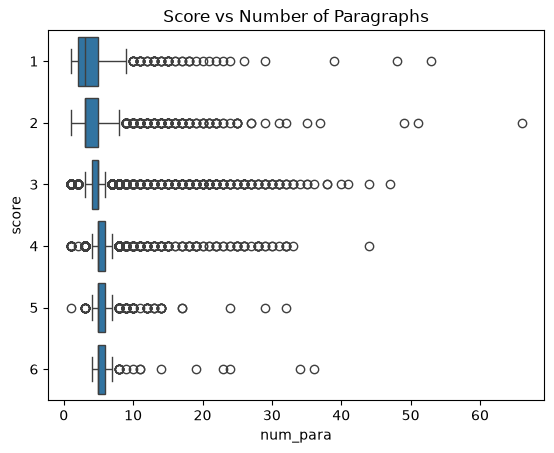

In [130]:
sns.boxplot(
    data = train_df,
    x = 'num_para',
    y = 'score',
    orient = 'h'
).set_title('Score vs Number of Paragraphs')

This trend is similar to the one above. Typically more words = more paragraphs, and thus more paragraphs generally had higher scores. However, it is more difficult to differentiate via. paragraphs than with words/sentences.

In [70]:
train_df.groupby('score').describe()

word_count                                                       \
           count        mean         std    min     25%    50%    75%   
score                                                                   
1         1252.0  302.135783  465.456053  148.0  194.00  240.0  323.0   
2         4723.0  284.614228  452.619817  148.0  197.00  238.0  301.0   
3         6280.0  367.153185  306.822852  149.0  285.00  340.0  409.0   
4         3926.0  479.863984  174.477921  224.0  399.00  460.0  533.0   
5          970.0  630.621649  136.341351  363.0  531.25  608.0  707.0   
6          156.0  768.692308  160.889127  493.0  663.00  743.0  846.0   

               num_sentences             ... num_para       para_length  \
           max         count       mean  ...      75%   max       count   
score                                    ...                              
1      11139.0        1252.0  14.018371  ...      5.0  53.0      1252.0   
2      19311.0        4723.0  14.163244  ...      5.0  66.0      4723.0   
3      14818.0        6280.0  19.642834  ...      5.0  47.0      6280.0   
4       7485.0        3926.0  25.426643  ...      6.0  44.0      3926.0   
5       1319.0         970.0  31.659794  ...      6.0  32.0       970.0   
6       1358.0         156.0  36.551282  ...      6.0  36.0       156.0   

                                                                              \
             mean         std        min         25%         50%         75%   
score                                                                          
1      125.155933  426.220726   6.250000   52.333333   74.500000  131.979167   
2       95.960594  192.414303   3.651515   53.500000   69.333333   95.000000   
3       84.883599   78.563019  10.027778   59.276786   74.708333   94.200000   
4       94.653687   50.408489  11.785714   73.800000   88.708333  107.000000   
5      117.822521   36.201542  16.551724   95.000000  113.200000  135.950000   
6      139.747685   44.782513  19.944444  113.362500  137.466667  159.800000   

                     
                max  
score                
1      11139.000000  
2       9180.000000  
3       2761.333333  
4       1497.000000  
5        500.000000  
6        338.000000  

[6 rows x 40 columns]

In [75]:
train_df['word_count'].describe()

count    17307.000000
mean       383.879008
std        352.141393
min        148.000000
25%        255.000000
50%        349.000000
75%        457.000000
max      19311.000000
Name: word_count, dtype: float64

In [86]:
print(train_df.loc[train_df['word_count']==19311])

     essay_id                                          full_text  score  \
4182  3dcfa42  I believe that the face on Mars is just a natu...      2   

      word_count  num_sentences  sentence_length  num_para  para_length  
4182       19311              9      2145.666667         5       3862.2  


It seems like there's an outlier, where someone wrote a lot but scored poorly.

In [91]:
train_df.sort_values(by='word_count')

,essay_id,full_text,score,word_count,num_sentences,sentence_length,num_para,para_length
2077,1f98766,I am going to write a essay about a aticle nam...,2,148,7,21.142857,5,29.600000
13790,ca5cb31,I belive what Luke is doing is grate to be hel...,2,148,11,13.454545,11,13.454545
13049,bff17b5,we shouldnt be able to use this technology on ...,1,148,8,18.500000,4,37.000000
16088,ed209df,Aliens had nothing to do with the face on Mars...,2,149,6,24.833333,3,49.666667
5126,4c6a800,The authors claim to keep studing venus is a v...,2,149,6,24.833333,2,74.500000
...,...,...,...,...,...,...,...,...
8312,7bccaa9,Technology can not tell you about someones emo...,2,9180,7,1311.428571,1,9180.000000
13777,ca42365,I am against the driverless cars because it wo...,1,11139,7,1591.285714,1,11139.000000
10788,9f5396a,if we look back at time in the united states y...,2,14714,3,4904.666667,3,4904.666667
893,0e47da5,Imagen the streets with no cars empty with onl...,3,14818,17,871.647059,6,2469.666667


In [110]:
train_df[train_df['word_count']>3000]

,essay_id,full_text,score,word_count,num_sentences,sentence_length,num_para,para_length
450,077eeea,The author supports the idea that studying Ven...,2,6041,14,431.500000,2,3020.500000
893,0e47da5,Imagen the streets with no cars empty with onl...,3,14818,17,871.647059,6,2469.666667
1196,12ea160,The face on Mars is definetly just a natural l...,3,8284,18,460.222222,3,2761.333333
1292,143fb6e,The face is fake. there is a lot of evadence t...,2,5617,11,510.636364,5,1123.400000
2603,270fe6b,I dont think that FACS should be able to be us...,3,8538,12,711.500000,5,1707.600000
2777,29835f7,The author shows us the many benifical factors...,2,8811,11,801.000000,3,2937.000000
4182,3dcfa42,I believe that the face on Mars is just a natu...,2,19311,9,2145.666667,5,3862.200000
4296,3fb1533,"Dear Senator,\n\nI favoring of keeping the Ele...",2,4703,12,391.916667,2,2351.500000
4653,455511f,A Car Free Future?\n\nIs the car necessary in ...,3,3682,15,245.466667,5,736.400000
5724,55b79be,"Dear senator,\n\nMany people argue that the el...",3,3260,21,155.238095,6,543.333333


In [121]:
train_df[(train_df['word_count']>1300) & (train_df['score']>=5)]

,essay_id,full_text,score,word_count,num_sentences,sentence_length,num_para,para_length
2803,29daf40,As the global concern for the environment incr...,5,1319,65,20.292308,5,263.8
8609,7fe2d12,"To the state and the state's country, the elec...",6,1358,48,28.291667,14,97.0
15824,e9831f4,When limiting car usage the first thing that m...,6,1352,64,21.125000,4,338.0


Essays with word counts below 1400 scored above a 5. No essays above word count 1400 scored above a 5.

In [ ]:
#Find max score for a 6 --> 1358
train_df[train_df['score']==6].sort_values(by='word_count')

,essay_id,full_text,score,word_count,num_sentences,sentence_length,num_para,para_length
16428,f260d4e,The author supports his arguement quite effect...,6,493,18,27.388889,6,82.166667
10174,963705b,The development of driverless cars is certainl...,6,502,26,19.307692,7,71.714286
14536,d62b9c4,It's safe to say that almost everyone on Earth...,6,515,34,15.147059,5,103.000000
5856,57fcfea,Mapping the Thoughts of Students\n\nIn the art...,6,517,28,18.464286,5,103.400000
828,0d2070c,Studying Venus is a worthy pursuit. Studying V...,6,549,22,24.954545,5,109.800000
...,...,...,...,...,...,...,...,...
14684,d8361b9,Body actions say more than words could ever sa...,6,1226,56,21.892857,6,204.333333
7369,6e990ee,"In a school, there are clasrooms upon classroo...",6,1231,53,23.226415,5,246.200000
5158,4d00492,"Dear Senator,\n\nConcerning the topic of the m...",6,1299,56,23.196429,8,162.375000
15824,e9831f4,When limiting car usage the first thing that m...,6,1352,64,21.125000,4,338.000000
